In [48]:
!{sys.executable} -m pip install --upgrade torch transformers datasets

In [49]:
import sys, torch
print(f"✅ Torch {torch.__version__} installed in: {sys.executable}")
print(f"🍎 MPS Available: {torch.backends.mps.is_available()}")

✅ Torch 2.11.0 installed in: /usr/local/bin/python3
🍎 MPS Available: True


In [50]:
# Add this at the VERY TOP of Cell 2, before any imports
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [51]:
!{sys.executable} -m pip install kagglehub

In [52]:
# 1: Set Up & Utilities
import os, time, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings("ignore")
 
# 🌱 Set seed globally
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass
 
# 🌱 Multi-seed wrapper
def run_with_seeds(train_fn, seeds=[42, 123, 7], **kwargs):
    metrics = {"acc": [], "f1": [], "train_time": [], "inf_time": []}
    raw_results = []
 
    for s in seeds:
        set_seed(s)
        res = train_fn(seed=s, **kwargs)
        raw_results.append({"seed": s, **res})
 
        for k in metrics:
            if f"test_{k}" in res:
                metrics[k].append(res[f"test_{k}"])
            elif k in res:
                metrics[k].append(res[k])
            else:
                raise KeyError(f"Missing metric '{k}' in result for seed {s}")
 
    summary = {
        k: {
            "mean": float(np.mean(v)),
            "std": float(np.std(v, ddof=1)) if len(v) > 1 else 0.0
        }
        for k, v in metrics.items()
    }
 
    return {"summary": summary, "raw_results": raw_results}
 
# 📏 Text Length & Truncation Analysis
def analyze_lengths(texts, tokenizer, max_len=512):
    lens = [len(tokenizer.encode(t, truncation=False)) for t in texts]
    stats = {
        "mean": float(np.mean(lens)),
        "median": float(np.median(lens)),
        "p95": float(np.percentile(lens, 95)),
        "max": int(np.max(lens)),
        "truncated": int(sum(l > max_len for l in lens)),
        "total": int(len(lens)),
        "truncated_pct": float(100 * sum(l > max_len for l in lens) / len(lens))
    }
 
    print(
        f"📊 Length Stats (tokens) | Mean: {stats['mean']:.1f} | "
        f"Median: {stats['median']:.1f} | P95: {stats['p95']:.1f} | Max: {stats['max']}"
    )
    print(
        f"🔪 {stats['truncated']}/{stats['total']} "
        f"({stats['truncated_pct']:.1f}%) exceed {max_len} tokens and will be truncated."
    )
    return stats
 
# ⚖️ Class Imbalance Check
def check_distribution(y, names):
    from collections import Counter
    cnt = Counter(y)
    total = len(y)
    rows = []
    for k, v in sorted(cnt.items()):
        rows.append({
            "class_id": k,
            "class_name": names[k],
            "count": v,
            "pct": 100 * v / total
        })
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return df

In [53]:
# 2: Load & Split Datasets
# 2A: Load & Split Newsgroups (via Kaggle Hub)
import os
import re
import kagglehub
from sklearn.model_selection import train_test_split

print("📥 Loading 20 Newsgroups from Kaggle...")

# Download dataset from Kaggle (no authentication required for public datasets)
base_path = kagglehub.dataset_download("crawford/20-newsgroups")

# Find all .txt files (each represents a newsgroup category)
txt_files = sorted([f for f in os.listdir(base_path) if f.endswith('.txt')])
if not txt_files:
    raise FileNotFoundError("No .txt files found in Kaggle download.")

# Create class names and label mapping
class_names = [f.replace('.txt', '') for f in txt_files]
label_map = {name: i for i, name in enumerate(class_names)}
print(f"📂 Found {len(class_names)} newsgroup files")

all_texts = []
all_labels = []

for cls in class_names:
    file_path = os.path.join(base_path, f"{cls}.txt")
    if not os.path.exists(file_path):
        continue
    
    with open(file_path, 'r', encoding='latin-1', errors='ignore') as f:
        raw = f.read()
    
    if not raw.strip():
        print(f"⚠️ {cls}.txt is empty. Skipping.")
        continue
    
    # Strategy 1: Split by double newline (handles \n\n and \r\n\r\n)
    docs = re.split(r'\r?\n\r?\n', raw)
    
    # Strategy 2: If Strategy 1 fails (<5 docs), split by Usenet header markers
    if len(docs) < 5:
        docs = re.split(r'(?=^From:|^Subject:|^Article-I\.D\.|^Path:)', raw, flags=re.MULTILINE)
    
    # Strategy 3: Fallback to single newline if still too few
    if len(docs) < 5:
        docs = raw.split('\n')
    
    docs_found = 0
    for doc in docs:
        doc = doc.strip()
        if len(doc) < 50:  # Skip very short documents
            continue
        
        # Light cleaning: remove header lines, keep body
        lines = doc.split('\n')
        cleaned = []
        in_header = True
        
        for line in lines:
            line_stripped = line.strip()
            
            if in_header:
                # Skip standard Usenet header fields
                if re.match(r'^(From|Subject|Organization|Date|Reply-To|Lines|Distribution|Keywords|Article-I\.D\.|NNTP-Posting-Host|Path|Message-ID|X-Newsreader|X-Trace|Posted|Followup-To):', line_stripped, re.I):
                    continue
                if line_stripped == '':
                    in_header = False
                    continue
                continue
            
            # Skip quotes/signatures
            if line_stripped.startswith('>') or line_stripped.startswith('|') or line_stripped.startswith('---') or line_stripped.startswith('___'):
                continue
            
            if line_stripped:
                cleaned.append(line_stripped)
        
        final_text = ' '.join(cleaned)
        if len(final_text) > 60:  # Keep only meaningful documents
            all_texts.append(final_text)
            all_labels.append(label_map[cls])
            docs_found += 1
    
    print(f"   📄 {cls}: {docs_found} docs loaded")

print(f"\n✅ Total 20NG documents: {len(all_texts)}")

if len(all_texts) == 0:
    # Fallback: print exact file stats so we can fix it in 1 message
    print("❌ Still zero documents. Printing file diagnostics:")
    print(f"   File: {file_path}")
    print(f"   Size: {len(raw)} bytes")
    print(f"   First 300 chars:\n{raw[:300]}")
    raise SystemExit("Reply with the diagnostics above so I can give you a 1-line fix.")

# Stratified Split: 80% Train, 10% Val, 10% Test
print("🔀 Splitting data (80/10/10)...")
X_train, X_temp, y_train, y_temp = train_test_split(
    all_texts, all_labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp
)

news_train = (X_train, y_train)
news_val = (X_val, y_val)
news_test = (X_test, y_test)
news_names = class_names

print(f"\n📊 20 Newsgroups Ready:")
print(f"   Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"   Sample text: '{X_train[0][:100]}...'")
print(f"   Sample label: {news_names[y_train[0]]}")

📥 Loading 20 Newsgroups from Kaggle...
📂 Found 20 newsgroup files
   📄 alt.atheism: 258 docs loaded
   📄 comp.graphics: 157 docs loaded
   📄 comp.os.ms-windows.misc: 140 docs loaded
   📄 comp.sys.ibm.pc.hardware: 120 docs loaded
   📄 comp.sys.mac.hardware: 142 docs loaded
   📄 comp.windows.x: 164 docs loaded
   📄 misc.forsale: 194 docs loaded
   📄 rec.autos: 90 docs loaded
   📄 rec.motorcycles: 118 docs loaded
   📄 rec.sport.baseball: 56 docs loaded
   📄 rec.sport.hockey: 204 docs loaded
   📄 sci.crypt: 228 docs loaded
   📄 sci.electronics: 114 docs loaded
   📄 sci.med: 206 docs loaded
   📄 sci.space: 128 docs loaded
   📄 soc.religion.christian: 138 docs loaded
   📄 talk.politics.guns: 170 docs loaded
   📄 talk.politics.mideast: 190 docs loaded
   📄 talk.politics.misc: 124 docs loaded
   📄 talk.religion.misc: 112 docs loaded

✅ Total 20NG documents: 3053
🔀 Splitting data (80/10/10)...

📊 20 Newsgroups Ready:
   Train: 2442 | Val: 305 | Test: 306
   Sample text: 'v)    To look into the 

In [54]:
import os
import glob
import kagglehub
import pandas as pd

print("📥 Loading TweetEval from Kaggle...")
path = kagglehub.dataset_download("thedevastator/tweeteval-a-multi-task-classification-benchmark")
print(f"📁 Dataset downloaded to: {path}")

# 1. Find all irony CSVs
all_csvs = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
irony_files = [f for f in all_csvs if "irony" in f.lower()]

if len(irony_files) < 3:
    raise ValueError(f"Could not find all 3 irony split files. Found: {[os.path.basename(f) for f in irony_files]}")

# 2. Robustly map split names to file paths
split_paths = {}
for f in irony_files:
    basename = os.path.basename(f).lower()
    if 'train' in basename and 'val' not in basename:
        split_paths['train'] = f
    elif 'validation' in basename or 'val' in basename:
        split_paths['validation'] = f
    elif 'test' in basename:
        split_paths['test'] = f

print(f"📄 Mapped splits: {list(split_paths.keys())}")

# 3. Load each split separately 
df_train = pd.read_csv(split_paths['train'])
df_val   = pd.read_csv(split_paths['validation'])
df_test  = pd.read_csv(split_paths['test'])

# 4. Identify columns dynamically
text_col = next((c for c in df_train.columns if c.lower() in ['text', 'tweet', 'sentence']), df_train.columns[0])
label_col = next((c for c in df_train.columns if c.lower() in ['label', 'class', 'target']), df_train.columns[1])
print(f"📊 Using column '{text_col}' for text and '{label_col}' for labels.")

tweet_names = ["non_ironic", "ironic"]

# 5. Clean & package into tuples (X, y)
def clean_split(df):
    df = df.dropna(subset=[text_col, label_col]).reset_index(drop=True)
    texts = df[text_col].astype(str).tolist()
    labels = df[label_col].astype(int).tolist()
    return (texts, labels)

tweet_train = clean_split(df_train)
tweet_val   = clean_split(df_val)
tweet_test  = clean_split(df_test)

print(f"\n✅ TweetEval Ready (Standard Splits):")
print(f"   Train: {len(tweet_train[0])} | Val: {len(tweet_val[0])} | Test: {len(tweet_test[0])}")
print(f"   Sample text: '{tweet_train[0][0][:80]}...'")
print(f"   Sample label: {tweet_names[tweet_train[1][0]]} (class {tweet_train[1][0]})")

📥 Loading TweetEval from Kaggle...
📁 Dataset downloaded to: /Users/ritail/.cache/kagglehub/datasets/thedevastator/tweeteval-a-multi-task-classification-benchmark/versions/2
📄 Mapped splits: ['test', 'validation', 'train']
📊 Using column 'text' for text and 'label' for labels.

✅ TweetEval Ready (Standard Splits):
   Train: 2862 | Val: 955 | Test: 784
   Sample text: 'seeing ppl walking w/ crutches makes me really excited for the next 3 weeks of m...'
   Sample label: ironic (class 1)


In [55]:
%pip install -U "accelerate>=1.1.0"

Note: you may need to restart the kernel to use updated packages.


In [68]:
# Step 1: Imports

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score

from datasets import Dataset
from setfit import SetFitModel, SetFitTrainer
from sentence_transformers import SentenceTransformer
from sentence_transformers.losses import CosineSimilarityLoss


In [69]:
# Optional but helpful: reproducibility helper

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except:
        pass


In [70]:
# Step 2: Point to your existing CSV

RESULT_FILE = "/Users/ritail/Documents/NUS Master Data Science for Sustainability/DSS5104 Machine Learning and Predictive Modelling /Assignment 2/results/cell6_tweeteval_all_models.csv"

SEEDS = [42, 123, 7]
SETFIT_FRACTIONS = {0.10, 0.05, 0.01}


In [90]:
# Step 3: Bind TweetEval splits for downstream experiments

X_train_full, y_train_full = tweet_train
X_val_full, y_val_full = tweet_val
X_test_full, y_test_full = tweet_test

print("TweetEval bindings ready")
print("Train:", len(X_train_full), "unique labels:", sorted(pd.Series(y_train_full).unique()))
print("Val:", len(X_val_full), "unique labels:", sorted(pd.Series(y_val_full).unique()))
print("Test:", len(X_test_full), "unique labels:", sorted(pd.Series(y_test_full).unique()))


TweetEval bindings ready
Train: 2862 unique labels: [np.int64(0), np.int64(1)]
Val: 955 unique labels: [np.int64(0), np.int64(1)]
Test: 784 unique labels: [np.int64(0), np.int64(1)]


In [91]:
# Step 4: Data efficiency settings

FRACTIONS = [1.0, 0.5, 0.25, 0.10, 0.05, 0.01]
SEEDS = [42, 123, 7]
SETFIT_FRACTIONS = {0.10, 0.05, 0.01}

RESULT_FILE = os.path.join(RESULTS_DIR, "tweeteval_data_efficiency_all_models_corrected.csv")

os.makedirs(RESULTS_DIR, exist_ok=True)


In [92]:
# Step 5: Reproducibility helper

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except:
        pass


In [93]:
# Step 6: SetFit helper with corrected TweetEval test usage

ALL_LABELS = sorted(list(set(y_train_full)))

def train_setfit_fraction(X_train, y_train, X_val, y_val, X_test_input, y_test_input, seed):
    set_seed(seed)
    t0 = time.time()

    train_ds = Dataset.from_dict({
        "text": list(X_train),
        "label": list(y_train)
    })

    val_ds = Dataset.from_dict({
        "text": list(X_val),
        "label": list(y_val)
    })

    body = SentenceTransformer("sentence-transformers/paraphrase-mpnet-base-v2")

    model = SetFitModel(
        model_body=body,
        model_head=LogisticRegression(max_iter=1000, random_state=seed),
        labels=ALL_LABELS
    )

    trainer = SetFitTrainer(
        model=model,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        loss_class=CosineSimilarityLoss,
        batch_size=16,
        num_iterations=20,
        num_epochs=1,
        column_mapping={"text": "text", "label": "label"},
    )

    trainer.train()

    preds = model.predict(list(X_test_input))
    acc = accuracy_score(y_test_input, preds)
    f1 = f1_score(y_test_input, preds, average="macro")

    return acc, f1, time.time() - t0


In [94]:
# Quick test run: only 1% fraction, 1 seed

TEST_FRACTIONS = [0.01]
TEST_SEEDS = [42]

print("Running quick corrected TweetEval test")

test_results = []

for frac in TEST_FRACTIONS:
    print(f"\nFraction: {frac:.0%}")

    X_sub, _, y_sub, _ = train_test_split(
        X_train_full,
        y_train_full,
        test_size=1.0 - frac,
        stratify=y_train_full,
        random_state=42
    )

    for seed in TEST_SEEDS:
        print(f"  Seed {seed}")
        set_seed(seed)

        vec = TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            sublinear_tf=True
        )
        X_sub_vec = vec.fit_transform(X_sub)
        X_test_vec = vec.transform(X_test_full)

        # TF-IDF + LR
        t0 = time.time()
        lr = LogisticRegression(
            max_iter=1000,
            C=1.0,
            random_state=seed,
            class_weight="balanced"
        )
        lr.fit(X_sub_vec, y_sub)
        pred_lr = lr.predict(X_test_vec)
        test_results.append({
            "dataset": "TweetEval",
            "fraction": frac,
            "samples": len(X_sub),
            "seed": seed,
            "model": "TF-IDF+LR",
            "accuracy": accuracy_score(y_test_full, pred_lr),
            "f1": f1_score(y_test_full, pred_lr, average="macro"),
            "train_time": time.time() - t0
        })

        # TF-IDF + SVM
        t0 = time.time()
        svm = SVC(kernel="linear", C=0.1, random_state=seed)
        svm.fit(X_sub_vec, y_sub)
        pred_svm = svm.predict(X_test_vec)
        test_results.append({
            "dataset": "TweetEval",
            "fraction": frac,
            "samples": len(X_sub),
            "seed": seed,
            "model": "TF-IDF+SVM",
            "accuracy": accuracy_score(y_test_full, pred_svm),
            "f1": f1_score(y_test_full, pred_svm, average="macro"),
            "train_time": time.time() - t0
        })

        # BiLSTM
        f1_bilstm, t_bilstm = train_bilstm_fraction(
            X_sub, y_sub, X_val_full, y_val_full, X_test_full, y_test_full, seed
        )
        test_results.append({
            "dataset": "TweetEval",
            "fraction": frac,
            "samples": len(X_sub),
            "seed": seed,
            "model": "BiLSTM",
            "accuracy": np.nan,
            "f1": f1_bilstm,
            "train_time": t_bilstm
        })

        # DistilBERT
        f1_distil, t_distil = train_transformer_fraction(
            "DistilBERT",
            "distilbert-base-uncased",
            tok_distil,
            X_sub, y_sub,
            X_val_full, y_val_full,
            X_test_full, y_test_full,
            seed
        )
        test_results.append({
            "dataset": "TweetEval",
            "fraction": frac,
            "samples": len(X_sub),
            "seed": seed,
            "model": "DistilBERT",
            "accuracy": np.nan,
            "f1": f1_distil,
            "train_time": t_distil
        })

        # RoBERTa
        f1_roberta, t_roberta = train_transformer_fraction(
            "RoBERTa",
            "roberta-base",
            tok_roberta,
            X_sub, y_sub,
            X_val_full, y_val_full,
            X_test_full, y_test_full,
            seed
        )
        test_results.append({
            "dataset": "TweetEval",
            "fraction": frac,
            "samples": len(X_sub),
            "seed": seed,
            "model": "RoBERTa",
            "accuracy": np.nan,
            "f1": f1_roberta,
            "train_time": t_roberta
        })

        # SetFit
        acc_setfit, f1_setfit, t_setfit = train_setfit_fraction(
            X_sub, y_sub, X_val_full, y_val_full, X_test_full, y_test_full, seed
        )
        test_results.append({
            "dataset": "TweetEval",
            "fraction": frac,
            "samples": len(X_sub),
            "seed": seed,
            "model": "SetFit",
            "accuracy": acc_setfit,
            "f1": f1_setfit,
            "train_time": t_setfit
        })

df_test_run = pd.DataFrame(test_results)
df_test_run


Running quick corrected TweetEval test

Fraction: 1%
  Seed 42


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8750.53it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'eval_loss': '0.6953', 'eval_f1': '0.3618', 'eval_runtime': '18.7', 'eval_samples_per_second': '51.07', 'eval_steps_per_second': '6.417', 'epoch': '1'}
{'eval_loss': '0.6942', 'eval_f1': '0.4114', 'eval_runtime': '18.3', 'eval_samples_per_second': '52.18', 'eval_steps_per_second': '6.557', 'epoch': '2'}
{'train_runtime': '41.28', 'train_samples_per_second': '1.357', 'train_steps_per_second': '0.194', 'train_loss': '0.685', 'epoch': '2'}


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8078.43it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'eval_loss': '0.7031', 'eval_f1': '0.3232', 'eval_runtime': '31.1', 'eval_samples_per_second': '30.71', 'eval_steps_per_second': '3.859', 'epoch': '1'}
{'eval_loss': '0.7022', 'eval_f1': '0.3232', 'eval_runtime': '30.28', 'eval_samples_per_second': '31.53', 'eval_steps_per_second': '3.962', 'epoch': '2'}
{'train_runtime': '67.37', 'train_samples_per_second': '0.831', 'train_steps_per_second': '0.119', 'train_loss': '0.7133', 'epoch': '2'}


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8348.00it/s]
MPNetModel LOAD REPORT from: sentence-transformers/paraphrase-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Map: 100%|██████████| 28/28 [00:00<00:00, 8186.29 examples/s]
***** Running training *****
  Num unique pairs = 1120
  Batch size = 16
  Num epochs = 1


Step,Training Loss
1,0.472073
50,0.144121


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


,dataset,fraction,samples,seed,model,accuracy,f1,train_time
0,TweetEval,0.01,28,42,TF-IDF+LR,0.552296,0.522773,0.023594
1,TweetEval,0.01,28,42,TF-IDF+SVM,0.557398,0.522836,0.021470
2,TweetEval,0.01,28,42,BiLSTM,NaN,0.527865,1.320403
3,TweetEval,0.01,28,42,DistilBERT,NaN,0.410986,42.534517
4,TweetEval,0.01,28,42,RoBERTa,NaN,0.284018,67.593092
5,TweetEval,0.01,28,42,SetFit,0.571429,0.552314,88.210002


In [95]:
print(df_test_run[["model", "accuracy", "f1", "train_time"]])


        model  accuracy        f1  train_time
0   TF-IDF+LR  0.552296  0.522773    0.023594
1  TF-IDF+SVM  0.557398  0.522836    0.021470
2      BiLSTM       NaN  0.527865    1.320403
3  DistilBERT       NaN  0.410986   42.534517
4     RoBERTa       NaN  0.284018   67.593092
5      SetFit  0.571429  0.552314   88.210002


In [96]:
# Step 7: Resume-safe corrected TweetEval data efficiency experiment

RESULT_FILE = os.path.join(RESULTS_DIR, "tweeteval_data_efficiency_all_models_corrected.csv")

if os.path.exists(RESULT_FILE):
    df_efficiency = pd.read_csv(RESULT_FILE)
    print("Loaded existing corrected results:", RESULT_FILE)
    print("Existing rows:", len(df_efficiency))
else:
    df_efficiency = pd.DataFrame(columns=[
        "dataset", "fraction", "samples", "seed", "model", "accuracy", "f1", "train_time"
    ])
    print("No corrected results file found. Starting fresh.")


No corrected results file found. Starting fresh.


In [97]:
def already_done(df, dataset, fraction, seed, model):
    if df.empty:
        return False

    match = df[
        (df["dataset"] == dataset) &
        (df["fraction"] == fraction) &
        (df["seed"] == seed) &
        (df["model"] == model)
    ]
    return len(match) > 0


In [98]:
def save_result_row(df, row, result_file):
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(result_file, index=False)
    return df


In [99]:
#step 7: corrected setfit for Data efficiency part
print("Running: Resume-safe corrected TweetEval Data Efficiency Experiment")

for frac in FRACTIONS:
    print(f"\nFraction: {frac:.0%}")

    if frac == 1.0:
        X_sub, y_sub = X_train_full, y_train_full
    else:
        X_sub, _, y_sub, _ = train_test_split(
            X_train_full,
            y_train_full,
            test_size=1.0 - frac,
            stratify=y_train_full,
            random_state=42
        )

    for seed in SEEDS:
        print(f"  Seed {seed}")
        set_seed(seed)

        # Build TF-IDF features only if needed
        need_tfidf = (
            not already_done(df_efficiency, "TweetEval", frac, seed, "TF-IDF+LR") or
            not already_done(df_efficiency, "TweetEval", frac, seed, "TF-IDF+SVM")
        )

        if need_tfidf:
            vec = TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                sublinear_tf=True
            )
            X_sub_vec = vec.fit_transform(X_sub)
            X_test_vec = vec.transform(X_test_full)

        # TF-IDF + Logistic Regression
        if already_done(df_efficiency, "TweetEval", frac, seed, "TF-IDF+LR"):
            print("    Skipping TF-IDF+LR")
        else:
            print("    Running TF-IDF+LR")
            t0 = time.time()
            lr = LogisticRegression(
                max_iter=1000,
                C=1.0,
                random_state=seed,
                class_weight="balanced"
            )
            lr.fit(X_sub_vec, y_sub)
            pred_lr = lr.predict(X_test_vec)

            row = {
                "dataset": "TweetEval",
                "fraction": frac,
                "samples": len(X_sub),
                "seed": seed,
                "model": "TF-IDF+LR",
                "accuracy": accuracy_score(y_test_full, pred_lr),
                "f1": f1_score(y_test_full, pred_lr, average="macro"),
                "train_time": time.time() - t0
            }
            df_efficiency = save_result_row(df_efficiency, row, RESULT_FILE)

        # TF-IDF + SVM
        if already_done(df_efficiency, "TweetEval", frac, seed, "TF-IDF+SVM"):
            print("    Skipping TF-IDF+SVM")
        else:
            print("    Running TF-IDF+SVM")
            t0 = time.time()
            svm = SVC(kernel="linear", C=0.1, random_state=seed)
            svm.fit(X_sub_vec, y_sub)
            pred_svm = svm.predict(X_test_vec)

            row = {
                "dataset": "TweetEval",
                "fraction": frac,
                "samples": len(X_sub),
                "seed": seed,
                "model": "TF-IDF+SVM",
                "accuracy": accuracy_score(y_test_full, pred_svm),
                "f1": f1_score(y_test_full, pred_svm, average="macro"),
                "train_time": time.time() - t0
            }
            df_efficiency = save_result_row(df_efficiency, row, RESULT_FILE)

        # BiLSTM
        if already_done(df_efficiency, "TweetEval", frac, seed, "BiLSTM"):
            print("    Skipping BiLSTM")
        else:
            print("    Running BiLSTM")
            f1_bilstm, t_bilstm = train_bilstm_fraction(
                X_sub, y_sub, X_val_full, y_val_full, X_test_full, y_test_full, seed
            )

            row = {
                "dataset": "TweetEval",
                "fraction": frac,
                "samples": len(X_sub),
                "seed": seed,
                "model": "BiLSTM",
                "accuracy": np.nan,
                "f1": f1_bilstm,
                "train_time": t_bilstm
            }
            df_efficiency = save_result_row(df_efficiency, row, RESULT_FILE)

        # DistilBERT
        if already_done(df_efficiency, "TweetEval", frac, seed, "DistilBERT"):
            print("    Skipping DistilBERT")
        else:
            print("    Running DistilBERT")
            f1_distil, t_distil = train_transformer_fraction(
                "DistilBERT",
                "distilbert-base-uncased",
                tok_distil,
                X_sub, y_sub,
                X_val_full, y_val_full,
                X_test_full, y_test_full,
                seed
            )

            row = {
                "dataset": "TweetEval",
                "fraction": frac,
                "samples": len(X_sub),
                "seed": seed,
                "model": "DistilBERT",
                "accuracy": np.nan,
                "f1": f1_distil,
                "train_time": t_distil
            }
            df_efficiency = save_result_row(df_efficiency, row, RESULT_FILE)

        # RoBERTa
        if already_done(df_efficiency, "TweetEval", frac, seed, "RoBERTa"):
            print("    Skipping RoBERTa")
        else:
            print("    Running RoBERTa")
            f1_roberta, t_roberta = train_transformer_fraction(
                "RoBERTa",
                "roberta-base",
                tok_roberta,
                X_sub, y_sub,
                X_val_full, y_val_full,
                X_test_full, y_test_full,
                seed
            )

            row = {
                "dataset": "TweetEval",
                "fraction": frac,
                "samples": len(X_sub),
                "seed": seed,
                "model": "RoBERTa",
                "accuracy": np.nan,
                "f1": f1_roberta,
                "train_time": t_roberta
            }
            df_efficiency = save_result_row(df_efficiency, row, RESULT_FILE)

        # SetFit only at low-data fractions
        if frac in SETFIT_FRACTIONS:
            if already_done(df_efficiency, "TweetEval", frac, seed, "SetFit"):
                print("    Skipping SetFit")
            else:
                print("    Running SetFit")
                acc_setfit, f1_setfit, t_setfit = train_setfit_fraction(
                    X_sub, y_sub, X_val_full, y_val_full, X_test_full, y_test_full, seed
                )

                row = {
                    "dataset": "TweetEval",
                    "fraction": frac,
                    "samples": len(X_sub),
                    "seed": seed,
                    "model": "SetFit",
                    "accuracy": acc_setfit,
                    "f1": f1_setfit,
                    "train_time": t_setfit
                }
                df_efficiency = save_result_row(df_efficiency, row, RESULT_FILE)

print("\nFinished corrected resume-safe run.")
print("Saved to:", RESULT_FILE)
print("Total rows:", len(df_efficiency))


Running: Resume-safe corrected TweetEval Data Efficiency Experiment

Fraction: 100%
  Seed 42
    Running TF-IDF+LR
    Running TF-IDF+SVM
    Running BiLSTM
    Running DistilBERT


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7248.05it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'eval_loss': '0.6016', 'eval_f1': '0.6774', 'eval_runtime': '13.17', 'eval_samples_per_second': '72.51', 'eval_steps_per_second': '9.111', 'epoch': '1'}
{'eval_loss': '0.6191', 'eval_f1': '0.6857', 'eval_runtime': '11.97', 'eval_samples_per_second': '79.78', 'eval_steps_per_second': '10.03', 'epoch': '2'}
{'train_runtime': '307.1', 'train_samples_per_second': '18.64', 'train_steps_per_second': '2.332', 'train_loss': '0.5544', 'epoch': '2'}
    Running RoBERTa


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8712.61it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'eval_loss': '0.6024', 'eval_f1': '0.6726', 'eval_runtime': '23.97', 'eval_samples_per_second': '39.85', 'eval_steps_per_second': '5.007', 'epoch': '1'}
{'eval_loss': '0.5577', 'eval_f1': '0.7182', 'eval_runtime': '21.64', 'eval_samples_per_second': '44.13', 'eval_steps_per_second': '5.545', 'epoch': '2'}
{'train_runtime': '536.8', 'train_samples_per_second': '10.66', 'train_steps_per_second': '1.334', 'train_loss': '0.5629', 'epoch': '2'}
  Seed 123
    Running TF-IDF+LR
    Running TF-IDF+SVM
    Running BiLSTM
    Running DistilBERT


...

{'eval_loss': '0.7036', 'eval_f1': '0.3232', 'eval_runtime': '25.32', 'eval_samples_per_second': '37.71', 'eval_steps_per_second': '4.739', 'epoch': '1'}
{'eval_loss': '0.7035', 'eval_f1': '0.3232', 'eval_runtime': '25.13', 'eval_samples_per_second': '38.01', 'eval_steps_per_second': '4.776', 'epoch': '2'}
{'train_runtime': '54.87', 'train_samples_per_second': '1.021', 'train_steps_per_second': '0.146', 'train_loss': '0.7201', 'epoch': '2'}
    Running SetFit


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9117.55it/s]
MPNetModel LOAD REPORT from: sentence-transformers/paraphrase-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Map: 100%|██████████| 28/28 [00:00<00:00, 20392.52 examples/s]
***** Running training *****
  Num unique pairs = 1120
  Batch size = 16
  Num epochs = 1


Step,Training Loss
1,0.472073
50,0.144500


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.13it/s]



Finished corrected resume-safe run.
Saved to: results/tweeteval_data_efficiency_all_models_corrected.csv
Total rows: 99


In [100]:
# Step 8: Summary table

summary_df = (
    df_efficiency
    .groupby(["fraction", "samples", "model"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        train_time_mean=("train_time", "mean"),
        train_time_std=("train_time", "std"),
    )
    .sort_values(["fraction", "model"], ascending=[False, True])
)

summary_df



,fraction,samples,model,accuracy_mean,accuracy_std,f1_mean,f1_std,train_time_mean,train_time_std
28,1.00,2862,BiLSTM,NaN,NaN,0.573642,0.055140,22.283931,7.325824
29,1.00,2862,DistilBERT,NaN,NaN,0.649995,0.013139,271.776508,30.979444
30,1.00,2862,RoBERTa,NaN,NaN,0.676235,0.042124,511.440045,22.225414
31,1.00,2862,TF-IDF+LR,0.66199,0.000000,0.652584,0.000000,0.015691,0.005502
32,1.00,2862,TF-IDF+SVM,0.51148,0.000000,0.496552,0.000000,0.836712,0.053288
23,0.50,1431,BiLSTM,NaN,NaN,0.565375,0.043244,9.560852,0.281674
24,0.50,1431,DistilBERT,NaN,NaN,0.612243,0.013744,137.384513,1.198499
25,0.50,1431,RoBERTa,NaN,NaN,0.547926,0.106281,271.062578,2.161863
26,0.50,1431,TF-IDF+LR,0.625,0.000000,0.612281,0.000000,0.010003,0.005944
27,0.50,1431,TF-IDF+SVM,0.436224,0.000000,0.368939,0.000000,0.250321,0.008544


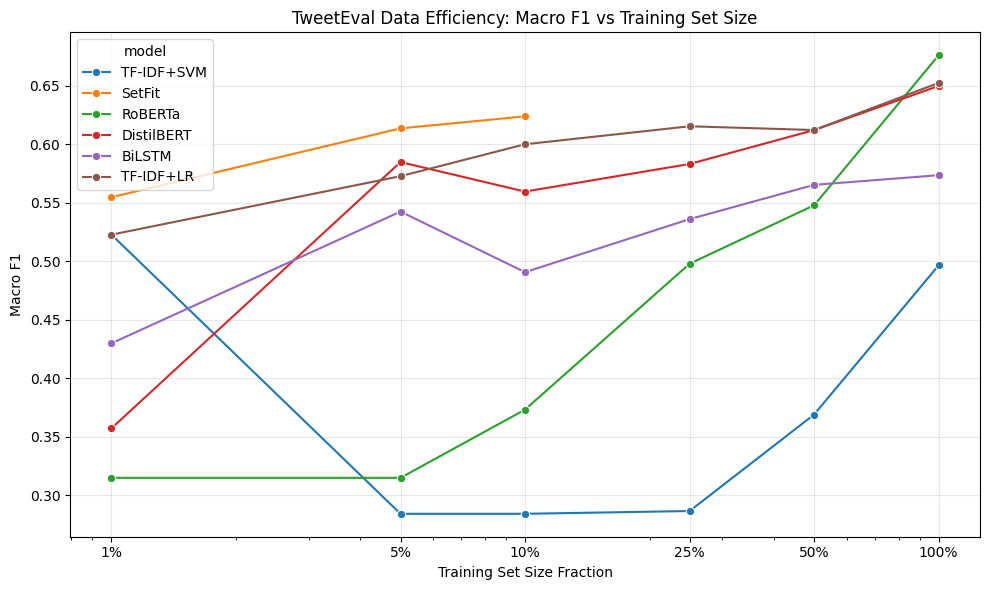

In [101]:
#Step 9:  Plot accuracy (or F1) vs. training set size for each method

plot_df = summary_df.sort_values("fraction").copy()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=plot_df,
    x="fraction",
    y="f1_mean",
    hue="model",
    marker="o"
)

plt.xscale("log")
plt.xticks(FRACTIONS, [f"{int(f * 100)}%" for f in FRACTIONS])
plt.xlabel("Training Set Size Fraction")
plt.ylabel("Macro F1")
plt.title("TweetEval Data Efficiency: Macro F1 vs Training Set Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [102]:
# step 9: crossover analysis 
def find_crossover(summary_df, baseline="TF-IDF+LR", target="DistilBERT", metric="f1_mean"):
    pivot = summary_df.pivot_table(
        index=["fraction", "samples"],
        columns="model",
        values=metric
    ).reset_index()

    pivot = pivot.sort_values("fraction")
    pivot = pivot.dropna(subset=[baseline, target])

    matches = pivot[pivot[baseline] >= pivot[target]]
    if len(matches) == 0:
        return None

    first_match = matches.iloc[0]
    return {
        "transformer": target,
        "crossover_fraction": float(first_match["fraction"]),
        "samples": int(first_match["samples"]),
        "tfidf_lr_f1": float(first_match[baseline]),
        "transformer_f1": float(first_match[target]),
    }

crossover_rows = []
for target in ["DistilBERT", "RoBERTa"]:
    result = find_crossover(summary_df, baseline="TF-IDF+LR", target=target)

    if result is None:
        crossover_rows.append({
            "transformer": target,
            "crossover_fraction": "No crossover",
            "samples": np.nan,
            "tfidf_lr_f1": np.nan,
            "transformer_f1": np.nan
        })
    else:
        crossover_rows.append({
            "transformer": target,
            "crossover_fraction": f"{int(result['crossover_fraction'] * 100)}%",
            "samples": result["samples"],
            "tfidf_lr_f1": round(result["tfidf_lr_f1"], 4),
            "transformer_f1": round(result["transformer_f1"], 4)
        })

crossover_df = pd.DataFrame(crossover_rows)
crossover_df


,transformer,crossover_fraction,samples,tfidf_lr_f1,transformer_f1
0,DistilBERT,1%,28,0.5228,0.3571
1,RoBERTa,1%,28,0.5228,0.3148


In [103]:
# Step 10: Best model by fraction

best_by_fraction = (
    summary_df
    .sort_values(["fraction", "f1_mean"], ascending=[False, False])
    .groupby("fraction", as_index=False)
    .first()[["fraction", "samples", "model", "f1_mean", "f1_std", "train_time_mean"]]
    .sort_values("fraction", ascending=False)
)

best_by_fraction


,fraction,samples,model,f1_mean,f1_std,train_time_mean
5,1.00,2862,RoBERTa,0.676235,0.042124,511.440045
4,0.50,1431,TF-IDF+LR,0.612281,0.000000,0.010003
3,0.25,715,TF-IDF+LR,0.615484,0.000000,0.008883
2,0.10,286,SetFit,0.623985,0.007312,599.025882
1,0.05,143,SetFit,0.613716,0.002376,308.462871
0,0.01,28,SetFit,0.554815,0.002166,73.518076
